In [1]:
from dotenv import load_dotenv
import os 
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import AzureChatOpenAI
from langchain_core.output_parsers import StrOutputParser

load_dotenv('../env', override=True)
AZURE_OPENAI_API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
END_POINT=os.getenv('END_POINT')
MODEL_NAME=os.getenv('MODEL_NAME')
if AZURE_OPENAI_API_KEY:
    print(AZURE_OPENAI_API_KEY[:10])
else:
    print("AZURE_OPENAI_API_KEY가 설정되지 않았습니다.")
print(MODEL_NAME)

AZURE_OPENAI_EMB_API_KEY = os.getenv('AZURE_OPENAI_EMB_API_KEY')
EMB_END_POINT=os.getenv('EMB_END_POINT')
EMB_MODEL_NAME=os.getenv('EMB_MODEL_NAME')

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_ENDPOINT'] = os.getenv('LANGCHAIN_ENDPOINT')
os.environ['LANGCHAIN_TRACING_V2'] = 'false' #true, false
os.environ['LANGCHAIN_PROJECT'] = 'AGENT'

if os.getenv('LANGCHAIN_TRACING_V2') == "true":
    langsmith_key = os.getenv('LANGSMITH_API_KEY')
    if langsmith_key and len(langsmith_key) > 0:
        print('랭스미스로 추적 중입니다 :', langsmith_key[:10])
    else:
        print('랭스미스 키가 확인되지 않았습니다.')

3BHTZdVIXx
gpt-5-nano


In [2]:
import os
from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    model=os.environ['MODEL_NAME'],
    azure_deployment=os.environ["MODEL_NAME"],
    azure_endpoint=os.environ["END_POINT"],
    openai_api_version="2025-03-01-preview",
    openai_api_key=os.environ["AZURE_OPENAI_API_KEY"],
)
llm.invoke("안녕!")

AIMessage(content='안녕! 반가워요. 어떻게 도와줄까요? 한국어 공부, 번역, 정보 찾기, 요리 레시피, 여행 팁, 코딩 문제 풀이 등 뭐든 도와줄 수 있어요.\n\n무슨 주제로 시작할까요?\n- 일상 대화 연습\n- 한국어 문법/표현 설명\n- 번역이나 문장 교정\n- 특정 주제에 대한 정보 찾기\n- 관심 있는 주제 이야기\n\n원하는 방향이나 질문이 있으면 바로 말해 주세요!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 637, 'prompt_tokens': 9, 'total_tokens': 646, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 512, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DD4pgCfcyRMg76nRaExvQ8f6qAqdf', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'viol

## Planning pattern 

**Orchestrator–Worker** 패턴으로, 주제 하나를 받아 **레포트 계획(섹션 목록)**을 세우고, **각 섹션을 병렬로 작성**한 뒤 하나의 최종 레포트로 통합 합니다.

### 그래프 흐름

1. 계획 단계 (Planner Node):
    - 플래너 에이전트가 사용자의 질문을 분석합니다.
    - 질문을 해결하기 위해 필요한 하위 작업 리스트를 생성합니다. (예: ['역사 조사', '경제 영향 분석', '미래 전망'])
1. 분기 결정 (Router):
    - 플래너가 만든 리스트를 바탕으로 Send 객체들의 리스트를 반환합니다.
    - return [Send("researcher", {"topic": t}) for t in topics]
1. 병렬 복제 및 실행 (Send):
    - 그래프 엔진은 researcher 노드를 주제 개수만큼 독립적인 인스턴스로 복제.
    - 이때 각 인스턴스는 동시에(Parallel) 실행
1. 상태 병합 (Fan-in):
    - 각각의 researcher가 작업을 마치고 결과를 반환하면, 결과들을 하나로 병합.
1. 최종 요약 (Final Reporter):
    - 모든 병렬 작업이 완료될 때까지 기다렸다가, 합쳐진 데이터를 바탕으로 최종 보고서를 작성.
---

### Send()

- 일반적인 그래프를 사용하면 구조가 고정되어야 하지만 send를 사용하면 실행 시점에 llm의 결과에 따라 자동으로 작ㅇ벋의 개수가 결정됨
- 병렬로 실행되므로 api를 사용할 경우 빠르게 동작할 수 있음(단, TPM 한계 주의)

```python
def assign_workers(state: State):
    return [Send("llm_call", {"section": s}) for s in state["sections"]]
```

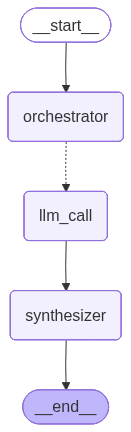

[values] {'topic': "'랭체인을 사용한 GraphRAG'를 강의하기 위한 강의안을 작성할거야. 이론과 실습을 통합하여 비전공자 수준에 맞춰 자세한 강의 초안을 작성해줘", 'completed_sections': []}
12개의 섹션 리스트가 생성되었습니다.
1. 강의 목표 및 대상
2. GraphRAG 이론의 배경
3. LangChain의 역할과 구성요소
4. GraphRAG 아키텍처 설계
5. 실습 준비 및 도구 설치
6. 실습 1: 기본 문서 기반 RAG(벤치마크) 구성
7. 실습 2: 그래프 데이터 연결 및 간단한 질의
8. 실습 3: 그래프 인덱스 + 벡터스토어의 GraphRAG 구성
9. 실습 4: 엔드투엔드 종합 예제
10. 평가 및 디버깅 전략
11. 확장 아이디어 및 보안/윤리 고려
12. 마무리 및 Q&A
--------------------------------
[updates] {'orchestrator': {'sections': [Section(section_index=1, name='1. 강의 목표 및 대상', description='목표: 비전공자도 LangChain 기반 GraphRAG의 아이디어를 이해하고, 간단한 엔드투엔드 파이프라인을 구성·실습해 볼 수 있다. \n대상: 데이터 과학/소프트웨어에 관심은 있지만 딥러닝·프로그래밍 경험이 기초인 학습자, 비전공자, 현업에서 지식 그래프와 LLM을 처음 다루는 팀원. \n수업 구성: 이론 50% + 실습 50%의 혼합형. 데모와 실습 예제 중심으로 진행. \n사전지식: 파이썬 기본 문법, 데이터베이스의 기본 개념, LLM의 간단한 작동 원리. \n준비물: 노트북, 파이썬 실행 환경, 네트워크 접근 권한(인터넷), 간단한 데이터셋 샘플.'), Section(section_index=2, name='2. GraphRAG 이론의 배경', description='핵심 개념: Retrieval-Augmented Generation(RAG)의 아이디어와 GraphRAG의 차별점. 

In [3]:
from typing import Annotated, List
import operator
from pydantic import BaseModel, Field
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langchain.messages import SystemMessage, HumanMessage, ToolMessage


# 계획 수립용 구조화 출력 스키마
class Section(BaseModel):
    """한 섹션의 이름과 설명"""
    section_index: int = Field(
        description="이 레포트 섹션의 인덱스.",
    )
    name: str = Field(
        description="이 레포트 섹션의 제목.",
    )
    description: str = Field(
        description="이 섹션에서 다룰 주요 주제와 개념에 대한 간단한 개요.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="레포트의 섹션 목록.",
    )


# 구조화 출력 스키마를 적용한 LLM
planner = llm.with_structured_output(Sections)

from langgraph.types import Send


# 그래프 상태
class State(TypedDict):
    topic: str  # 레포트 주제
    sections: list[Section]  # 레포트 섹션 목록
    completed_sections: Annotated[
        list, operator.add  #<--- 이 리듀서가 있어야 병렬로 실행되는 노드들의 결과를 합칠 수 있음. 자칫 잘못하면 덮어써지거나 충돌이 생길 수 있음음
    ]  # 모든 워커가 병렬로 이 키에 기록
    final_report: str  # 최종 레포트


class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


def orchestrator(state: State):
    """레포트 계획을 생성하는 오케스트레이터"""

    report_sections = planner.invoke(
        [
            SystemMessage(content="주어진 주제에 맞춰 한국어로 레포트 계획을 생성하세요. 레포트 섹션이름 앞에는 섹션 번호를 붙이세요."),
            HumanMessage(content=f"레포트 주제: {state['topic']}"),
        ]
    )
    print(f'{len(report_sections.sections)}개의 섹션 리스트가 생성되었습니다.')
    for section in report_sections.sections:
        print(f'{section.name}')
    print('--------------------------------')

    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    """워커가 레포트의 한 섹션을 작성"""

    # 섹션 본문 생성
    section = llm.invoke(
        [
            SystemMessage(
                content="""주어진 섹션 제목과 설명에 맞게 레포트 섹션을 작성하세요. 
                각 섹션 앞에 서론을 붙이지 마세요. 마크다운 형식을 사용하세요.
                각 섹션 제목의 수준은 소제목 ## 이어야 합니다.
                제목 앞에는 message에 전달된 섹션 번호를 붙이세요."""
            ),
            HumanMessage(
                content=f"섹션 제목: {state['section'].name}, 설명: {state['section'].description}"
            ),
        ]
    )

    # 완료된 섹션 목록에 추가
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """완료된 섹션들을 합쳐 최종 레포트 생성"""

    # 완료된 섹션 목록
    completed_sections = state["completed_sections"]

    # 완료된 섹션을 문자열로 이어 붙여 최종 레포트 구성
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}

# 각 섹션마다 llm_call 워커를 두는 조건부 엣지 함수
def assign_workers(state: State):
    """계획의 각 섹션에 워커 한 명씩 할당"""

    # Send() API로 섹션 작성 작업을 병렬로 시작
    return [Send("llm_call", {"section": s}) for s in state["sections"]]


# 워크플로 구성
orchestrator_worker_builder = StateGraph(State)

orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

orchestrator_worker = orchestrator_worker_builder.compile(debug=True)

display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

state = orchestrator_worker.invoke({"topic": "'랭체인을 사용한 GraphRAG'를 강의하기 위한 강의안을 작성할거야. 이론과 실습을 통합하여 비전공자 수준에 맞춰 자세한 강의 초안을 작성해줘"})


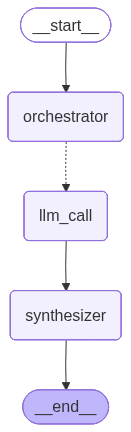

In [4]:
from IPython.display import display, Image

display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [5]:
from IPython.display import Markdown
Markdown(state["final_report"])

## 1. 강의 목표 및 대상

- 목표: 비전공자도 LangChain 기반 GraphRAG의 아이디어를 이해하고, 간단한 엔드투엔드 파이프라인을 구성·실습해 볼 수 있다.
- 대상: 데이터 과학/소프트웨어에 관심은 있지만 딥러닝·프로그래밍 경험이 기초인 학습자, 비전공자, 현업에서 지식 그래프와 LLM을 처음 다루는 팀원.
- 수업 구성: 이론 50% + 실습 50%의 혼합형으로 진행되며, 데모와 실습 예제 중심.
- 사전지식: 파이썬 기본 문법, 데이터베이스의 기본 개념, LLM의 간단한 작동 원리.
- 준비물: 노트북, 파이썬 실행 환경, 네트워크 접근 권한(인터넷), 간단한 데이터셋 샘플.

---

## 2. GraphRAG 이론의 배경

GraphRAG은 대형 언어모델이 외부 지식을 효과적으로 활용하도록 설계된 Retrieval-Augmented Generation(RAG)의 확장 개념이다. RAG는 외부 자료를 검색해 정보를 보완하는 아키텍처로, 검색기와 생성기가 협력해 최종 출력을 구성한다. GraphRAG은 여기에 그래프(지식 그래프) 컨텍스트를 함께 도입해 더 구조적이고 연결된 맥락을 제공한다.

- 핵심 개념
  - RAG의 아이디어: 대형 언어모델이 외부 자료를 검색해 보완 정보를 받아들이고, 검색 결과를 바탕으로 더 정확하고 풍부한 응답을 생성하도록 하는 아키텍처.
  - GraphRAG의 차별점: 그래프 컨텍스트를 함께 포함해 노드/엣지의 연결 정보를 활용해 관련 문맥을 확장하고, 그래프 내의 서브그래프를 프롬프트에 포함시켜 LLM의 출력 품질을 높임.

- 주요 용어
  - 임베딩(벡터화): 텍스트를 연속적인 벡터 공간으로 매핑해 의미를 벡터로 표현하는 기법.
  - 벡터저장소(vector store): 임베딩 벡터를 저장하고 유사도 검색에 활용하는 인덱스 시스템.
  - 지식그래프(노드/엣지): 엔티티를 노드로, 관계를 엣지로 표현한 구조화된 지식 표현.
  - 서브그래프: 지식그래프의 특정 부분을 구성하는 연결된 노드와 엣지의 부분집합.
  - 트리거링 트리거(prompt chaining): 다단계 프롬프트를 연결해 점진적으로 추론을 진행하는 기법.

- 왜 필요할까?
  - 텍스트 문서만으로는 경계가 모호한 지식이나 상호 연결 정보를 충분히 전달하기 어렵기 때문.
  - 그래프 정보를 포함하면 구조적 관계를 명시적으로 표현할 수 있어, 관련 맥락의 확장과 해석의 명확성을 높일 수 있다.
  - 서브그래프를 프롬프트에 포함시키면 LLM가 그래프의 구조적 정보를 활용해 더 정교한 추론과 응답을 생성할 가능성이 증가한다.

---

## 3. LangChain의 역할과 구성요소

LangChain은 LLM과 도구, 체인, 메모리, 데이터 소스 간의 흐름을 구성하는 프레임워크다. 다양한 구성요소를 연결해 복합적인 질의응답 파이프라인과 에이전트를 구축하고, 외부 자원 활용과 컨텍스트 관리의 복합성을 관리한다. 핵심 아이디어는 LLM의 언어 처리 능력과 외부 자원의 실시간 활용을 체계적으로 연결하는 것에 있다.

주요 구성요소:
- LLM: 실제 질의 응답의 핵심 모델로, 예를 들어 OpenAI의 GPT 계열이나 Hugging Face의 모델 등을 말합니다. 프롬프트 설계, 컨텍스트 길이 관리, 모델 버전 선택 등 운영상의 의사결정과 람다 조합을 통해 응답 품질을 결정한다. Tools와의 인터페이스를 통해 외부 자원에 접근하는 역할도 수행한다.
- 체인(Chain): 입력으로부터 출력을 생성하는 처리 파이프라인이다. RetrievalQA, ConversationalRetrievalQA 등 다양한 형태의 파이프라인이 가능하며, LLM, Tools, VectorStore, Memory 간의 흐름을 정의한다. 모듈화된 구성으로 재사용성과 구성을 용이하게 한다.
- 도구(Tools): 외부 API 호출, 데이터베이스 질의, 그래프 질의 등 외부 자원에 접근하는 인터페이스다. LLM의 호출 맥락에서 필요한 정보를 실시간으로 수집하거나 특정 작업을 수행하도록 돕는다. Tools는 프롬프트 대신 실행 로직과 연결되어 LLM의 응답 범위를 확장한다.
- 벡터스토어(VectorStore): 임베딩 생성과 빠른 유사도 검색을 담당한다. 문서 요약의 컨텍스트를 찾거나 관련 정보를 신속하게 찾아내는 데 사용되며, FAISS, Pinecone, Weaviate 등 다양한 구현이 있다. Retrieval 흐름에서 핵심 컨텍스트를 공급하는 역할을 한다.

GraphRAG에의 적용:
- 그래프 기반의 질의 전처리: 그래프 구조를 활용해 쿼리의 도메인 엔티티와 관계를 식별하고, 관련 컨텍스트의 후보를 선별한다.
- 그래프에서의 컨텍스트 추출: 그래프 노드의 텍스트 속성, 경로 정보, 노드 간 관계를 컨텍스트로 추출해 LLM에 넣을 자료를 구성한다.
- 벡터스토어와의 결합: 그래프에서 추출한 컨텍스트를 임베딩해 벡터스토어에 저장/검색하고, 관련 벡터를 바탕으로 추가 정보를 확보한다.
- LLM으로의 최종 응답 생성 흐름 구성: 검색된 컨텍스트를 LLM에 전달해 최종 응답을 생성하며, 필요 시 도구 호출을 통해 보완된 정보를 반영한다.

---

## 4. GraphRAG 아키텍처 설계

- 고수준 아키텍처 구성
  - 데이터 계층: 텍스트 문서, 속성정보를 가진 지식그래프(노드/엣지), 필요시 메타데이터 포함.
  - 임베딩 계층: 각 노드/문서의 텍스트를 임베딩 벡터로 변환. 벡터스토어(예: FAISS, Chroma) 저장.
  - 그래프 조회계: 쿼리 의도에 맞춰 그래프에서 관련 서브그래프를 탐색하고, 해당 서브그래프의 텍스트를 수집.
  - 그래프-임베딩 융합: 노드 텍스트와 서브그래프의 구조 정보를 함께 프롬프트에 반영하기 위한 포맷 설계.
  - LLM 체인: 최종 질의에 대한 응답 생성을 LLM이 수행하도록 Retrieval-augmented 파이프라인 구성. LangChain 기반의 RetrievalQA/GraphRetriever를 활용.
- 실습 포인트
  - 간단한 Neo4j/타 그래프 DB 예시를 사용해 그래프 쿼리와 임베딩-벡터 검색의 연결 고리를 이해하도록 설계.

---

## 5. 실습 준비 및 도구 설치

- 가상환경 생성
  - 파이썬 가상환경 생성 및 활성화 명령:
    - ```bash
      python3 -m venv venv
      source venv/bin/activate
      ```

- 핵심 패키지 설치
  - 필수 라이브러리 설치:
    - ```bash
      pip install langchain openai transformers faiss-cpu neo4j-driver py2neo
      ```

- 벡터스토어 예시 설치
  - 옵션 A: faiss-cpu 설치
    - ```bash
      pip install 'faiss-cpu'
      ```
  - 옵션 B: LangChain의 기본 벡터스토어 사용
    - 추가 설치 없이 기본 벡터스토어를 활용할 수 있으나, 운영 환경에 따라 설정이 필요할 수 있습니다.
      - (권장) 필요 시 LangChain 문서의 벡터스토어 가이드를 참조

- 그래프 DB 준비
  - 로컬 Neo4j 설치 또는 Docker 이용 예시
  - Docker 실행 예시:
    - ```bash
      docker run -p 7687:7687 -p 7474:7474 -e NEO4J_AUTH=neo/neo -d neo4j:latest
      ```
  - 참고: 로컬 설치를 선호하는 경우 운영체제에 맞는 Neo4j 설치 패키지와 설정을 추가로 따라 진행

- 예제 데이터 준비
  - 간단한 그래프 노드/엣지 샘플과 문서 샘플 데이터 세트를 준비
  - 예시 데이터 구성 아이디어
    - 노드: { id, label: [Person|Document], properties }
    - 엣지: { source_id, target_id, relation: [KNOWS|REFERENCES|CONTAINS], properties }
    - 문서 샘플: { doc_id, title, content }
  - 데이터 포맷 예시 (JSON)
    - ```json
      {
        "nodes": [
          {"id": "p1", "label": "Person", "name": "Alice"},
          {"id": "p2", "label": "Person", "name": "Bob"},
          {"id": "d1", "label": "Document", "title": "Intro to 그래프DB"}
        ],
        "edges": [
          {"source": "p1", "target": "p2", "relation": "KNOWS"},
          {"source": "p1", "target": "d1", "relation": "REFERENCES"}
        ]
      }
      ```

- API 키 관리
  - 안전하게 API 키를 관리하는 방법
    - 환경변수 사용: OpenAI 등의 API 키를 시스템 환경변수로 설정
      - 예: `export OPENAI_API_KEY=sk-...`
    - .env 사용 권고: 로컬 개발 시 .env 파일에 키를 보관하고 dotenv 로드 방식으로 읽어 사용
      - .env 예시:
        - ```
          OPENAI_API_KEY=sk-...
          ```
      - 파이썬에서 읽기 예시:
        - ```python
          from dotenv import load_dotenv
          import os
          load_dotenv()
          openai_api_key = os.getenv("OPENAI_API_KEY")
          ``` 
  - 주의사항
    - 키를 코드에 하드코딩하지 말 것
    - 버전 관리 시스템에 키를 절대 커밋하지 말 것
    - 필요 시 비밀 관리 서비스(예: AWS Secrets Manager, Google Secret Manager) 도입 고려

---

## 6. 실습 1: 기본 문서 기반 RAG(벤치마크) 구성

- 목표
  GraphRAG의 핵심 흐름을 간단한 문서 기반으로 이해하고, LangChain의 RetrievalQA를 활용한 기본 파이프라인을 구축해 보기.

- 실습 단계
  1) 샘플 문서 생성: 주제별 텍스트 문서 배열 생성
  2) 임베딩 및 벡터스토어 구축: OpenAIEmbeddings + FAISS 사용
  3) RetrievalQA 구성: llm=OpenAI/LangChain 기본 LLM, retriever 벡터스토어 연결
  4) 간단한 질의 테스트: "그래프 데이터의 기본 개념은 무엇인가?" 등

- 예시 코드 스켈톤
  ```python
  from langchain.llms import OpenAI
  from langchain.embeddings import OpenAIEmbeddings
  from langchain.vectorstores import FAISS
  from langchain.chains import RetrievalQA

  embeddings = OpenAIEmbeddings()
  docs = ["Graph RAG의 정의는...", "벡터스토어의 역할은...", "질의 응답 흐름은..."]
  vstore = FAISS.from_texts(docs, embeddings)
  qa = RetrievalQA.from_chain_type(llm=OpenAI(model_name="gpt-3.5-turbo"), chain_type="stuff", retriever=vstore.as_retriever())
  print(qa.run("그래프 기반 RAG의 핵심은 무엇인가?"))
  ```

---

## 7. 실습 2: 그래프 데이터 연결 및 간단한 질의

목표
- Neo4j와 파이썬 연동을 통해 그래프 데이터를 생성하고 간단한 질의를 수행한다.

실습 단계
1) Neo4j 연결 코드 작성(py2neo 또는 neo4j-driver 사용)
- Bolt 프로토콜과 인증 정보를 사용해 그래프 데이터베이스에 연결한다.
2) 간단한 노드/엣지 생성: Topic, Document 노드 및 RELATED 관계 구성
- Topic 노드와 Document 노드를 생성하고, 두 노드를 RELATED 관계로 연결한다.
3) Cypher 쿼리로 관련 문서/주제 조회
- 생성된 관계를 참조해 관련 문서를 조회하고 결과를 확인한다.

예시 코드
```python
from py2neo import Graph

# Neo4j 연결
graph = Graph("bolt://localhost:7687", auth=("neo", "neo"))

# 노드/관계 생성
graph.run("CREATE (t:Topic {name:'GraphRAG'})-[:RELATED]->(d:Document {content:'LangChain과 GraphRAG의 연계'})")

# 간단한 질의: GraphRAG 토픽에 연결된 문서 조회
rows = graph.run("MATCH (t:Topic {name:'GraphRAG'})-[:RELATED]->(d:Document) RETURN d.content LIMIT 5").data()
print(rows)
```

검증 및 주의사항
- Neo4j 서버가 실행 중이고 포트 및 자격 증명이 올바른지 확인한다.
- 중복 노드/관계 생성을 피하기 위해 MERGE를 사용할지 CREATE를 사용할지 상황에 따라 선택한다.
- 복잡한 쿼리는 트랜잭션 관리와 예외 처리를 추가해 안정성을 높인다.

---

## 8. 실습 3: 그래프 인덱스 + 벡터스토어의 GraphRAG 구성

### 목표
그래프에서 엔티티를 먼저 식별하고, 해당 엔티티의 서브그래프와 연결된 텍스트를 임베딩-벡터저장소로 구성한다. 이를 바탕으로 그래프 컨텍스트를 포함한 질의 프롬프트를 설계하고, GraphRAG 파이프라인을 통해 LLM 응답을 생성한다.

### 실습 흐름
1) 그래프에서 관련 노드 선별: 쿼리의 의도에 맞춘 노드를 찾는다.  
2) 서브그래프 텍스트 수집 및 임베딩: 선별된 노드의 서브그래프에 포함된 텍스트를 수집하고 임베딩 후 벡터스토어에 저장한다.  
3) 프롬프트 설계: 그래프 컨텍스트를 포함한 질의 프롬프트를 구성한다.  
4) LLM 응답 생성: GraphRAG 파이프라인을 실행해 질의에 대한 응답을 생성한다.

### 코드 아이디어
- 그래프에서 서브그래프를 가져오는 함수(예: Cypher로 상위 노드 수집)
- 수집 텍스트를 벡터스토어에 저장
- LLM에 컨텍스트 포함 포맷으로 프롬프트 전달

코드 아이디어 예시

```python
# 1) 서브그래프 가져오기: Cypher를 이용해 관련 노드/상위 노드들을 수집하는 아이디어
def get_subgraph_nodes(query_node_id: str, depth: int = 2):
    cypher = f"""
    MATCH (n:Entity {{id: $id}})-[*1..{depth}]-(m)
    RETURN DISTINCT n, m
    """
    # pseudo 실행
    result = graph_session.run(cypher, id=query_node_id)
    return parse_nodes(result)  # 노드 목록으로 변환
```

```python
# 2) 수집 텍스트를 벡터스토어에 저장하는 아이디어
def embed_and_store_texts(texts, vector_store, embedding_model):
    # texts: List[str], 각 텍스트에 대한 메타데이터 포함
    embeddings = embedding_model.embed_batch(texts)  # 벡터 생성
    for text, emb in zip(texts, embeddings):
        vector_store.add_vector(emb, metadata={"text": text})
```

```python
# 3) 프롬프트 설계: 그래프 컨텍스트를 포함한 질의 프롬프트 구성 예시
def build_graph_context_prompt(graph_context: str, question: str, retrieved_texts: list):
    context_text = "\n".join([f"- {t['text']}" for t in retrieved_texts])
    prompt = (
        f"그래프 컨텍스트:\n{graph_context}\n\n"
        f"관련 텍스트(서브그래프 텍스트):\n{context_text}\n\n"
        f"질문: {question}\n"
        f"응답 형식: 그래프 컨텍스트를 참조한 답변"
    )
    return prompt
```

```python
# 4) GraphRAG 파이프라인 실행: LLM에 컨텍스트를 포함한 프롬프트 전달 및 응답 생성 아이디어
def answer_with_graph_rag(prompt, llm_model, vector_store, top_k=5):
    # 프롬프트의 임베딩으로 관련 문서를 검색
    prompt_embedding = llm_model.embed(prompt)
    retrieved = vector_store.similarity_search(prompt_embedding, k=top_k)
    augmented_prompt = prompt + "\n참고 자료:\n" + "\n".join([d.metadata["text"] for d in retrieved])
    # LLM 호출
    return llm_model.generate(augmented_prompt)
```

참고로 위 코드는 아이디어 차원의 의사 코드이며, 실제 구현 시 사용하는 그래프 데이터베이스(Cypher/Cypher-like 쿼리), 임베딩 모델, 벡터스토어의 API에 맞춰 함수 시그니처와 호출 방식을 조정하면 된다.

---

## 9. 실습 4: 엔드투엔드 종합 예제

- 목표
  - 사용자의 질의에 대해 GraphRAG로 컨텍스트를 수집하고, 이를 기반으로 벡터저장소 확장을 거친 뒤 LLM으로 최종 응답까지 생성하는 엔드투엔드 흐름을 구현한다.

- 파이프라인 개요
  - 입력: 사용자 질의
  - 그래프 기반 초기 해석 및 관련 노드 탐색
  - 노드 텍스트 + 서브그래프를 벡터저장소 검색으로 확장
  - 프롬프트 구성: 그래프 컨텍스트 + 질의
  - LLM 응답 생성 및 서빙 포맷(답변 + 부가 정보/참고 링크)

- 구현 구성 요소
  - 그래프 데이터 모델: 노드와 에지로 구성된 지식 네트워크
  - 그래프 해석 엔진: 질의에 연관된 노드를 선택하는 초기 해석 로직
  - 벡터 저장소: 노드 텍스트 및 서브그래프 정보를 임베딩하고 저장
  - 임베딩 및 검색 파이프라인: 임베딩 생성 모델과 벡터 유사도 검색
  - 프롬프트 엔진: 그래프 컨텍스트와 질의를 결합하는 프롬프트 구성
  - LLM 호출 핸들러: API 호출, 응답 수집 및 포맷 정리
  - 서빙 포맷: 답변 텍스트와 함께 부가 정보/참고 링크를 포함하는 출력 구조

- 데이터 흐름 예시
  - 질의 입력 → 그래프 탐색으로 초기 후보 노드 도출 → 노드 텍스트 및 서브그래프를 벡터저장소에서 확장 검색 → 컨텍스트 구성(그래프 컨텍스트 + 질의) → LLM 응답 생성 및 포맷화 → CLI/노트북에서 출력

- 실습 결과물(실행 가능한 파이프라인 코드)
  - 주요 코드 구조 예시
    - main.py 또는 app.py: 엔드투엔드 파이프라인 실행 엔트리
    - graph_rag.py: 그래프 해석 및 초기 노드 탐색 로직
    - vector_store.py: 벡터 저장소 인터페이스(임베딩 생성/저장/검색)
    - prompts.py: 프롬프트 구성 로직
    - llm.py: LLM 호출 핸들러(스트리밍/비동기 지원Optional)
  - 예시 실행 흐름(CLI 예)
    - python main.py --query "질의 내용"
  - 예시 코드 스니펫(간단한 흐름)
    ```
    def run_end2end(query: str):
        # 1) 그래프 기반 초기 해석 및 노드 탐색
        nodes = graph_search(query)
        # 2) 노드 텍스트 + 서브그래프를 벡터저장소 검색으로 확장
        texts = [n.text for n in nodes]
        subgraph = extract_subgraph(nodes)
        embeddings = embed_texts(texts + [subgraph.text])
        top_context = vector_store.similarity_search(embeddings, top_k=5)
        # 3) 프롬프트 구성
        prompt = build_prompt(context=top_context, query=query)
        # 4) LLM 응답 생성 및 포맷
        raw_response = llm_call(prompt)
        output = format_response(raw_response, sources=top_context)
        return output
    ```
  - 기대 산출물
    - 간단한 CLI 또는 주피터 노트북에서 실행 가능한 엔드투엔드 파이프라인
    - 그래프 컨텍스트와 질의를 기반으로 한 응답 및 참고 링크를 포함하는 서빙 포맷

- 구현 시 고려사항
  - 그래프 규모에 따른 탐색 효율성 및 캐시 전략
  - 벡터스토어의 업데이트 정책과 지속성
  - 프롬프트 길이 제한 및 맥락 창 관리
  - 프라이버시 및 데이터 출처 표기(참고 링크의 신뢰성 관리)
  - 로컬/원격 실행 환경에 따른 의존성 관리와 재현성 확보

- 산출물 구성 예시
  - README.md: 사용 방법과 실행 예시
  - requirements.txt: 파이프라인 의존성
  - src/ 디렉토리 구조: graph_rag.py, vector_store.py, prompts.py, llm.py, main.py
  - notebooks/ 실습 노트북: 입력 질의에 대한 엔드투엔드 흐름 데모
  - tests/ 간단한 테스트 케이스: 노드 탐색, 임베딩, 프롬프트 구성의 기본 동작 확인

- 확장성 제언
  - 그래프 업데이트를 이벤트 기반으로 자동 반영
  - 다중 카테고리 노드에 대한 컨텍스트 가중치 조정
  - 다양한 LLM 공급자 및 프롬프트 템플릿의 플러그인화
  - 실험적 프롬프트 캐시 및 재생성 로직 도입

---

## 10. 평가 및 디버깅 전략

성능 평가 포인트:
- 정확도/관련성: 질의-그래프 컨텍스트 간의 적합성 평가
- 응답의 일관성: 업데이트된 지식 그래프에서의 일관성
- 응답 길이와 명료도: 요약 품질, 필요시 근거 제시 여부

디버깅 전략:
- 람다(로그) 수준 관리, 각 모듈별 로그 출력
- 그래프 쿼리의 실행 계획 확인(Cypher)
- 벡터스토어 임베딩 품질 점검(임베딩 차원, 유사도 임계값 조정)
- LLM 프롬프트 파라미터 실험(preamble, system 메시지, temperature 조절)
- 예외 케이스 테스트: 질의가 그래프 밖의 정보일 때의 처리

---

## 11. 확장 아이디어 및 보안/윤리 고려

확장 아이디어:
- 다층 그래프 인덱싱, 동적 그래프 업데이트, 실시간 데이터 연동
- 다중 소스(RDBMS, 문서 저장소, 데이터레이크) 결합
- 그래프 기반 컨텍스트의 다중 프롬프트 실험(파생 프롬프트, 다양한 포맷)

보안/윤리 고려:
- 데이터 소유권과 라이선스, 민감정보 비식별화
- API 키 관리와 호출 비용 관리
- LLM의 응답에 대한 출처 명시 및 사실 확인 절차

---

## 12. 마무리 및 Q&A

- 수업 요약
  - GraphRAG의 핵심 흐름
    - 데이터 수집 및 전처리 → 임베딩 생성 및 벡터 저장소 구성 → 질의 시 관련 문서 후보 검색 및 전처리/정제 → 그래프 기반 관계 정보로 후보 문서의 맥락 강화 및 재정렬 → LangChain으로 프롬프트 설계 및 체인 실행 → 생성된 답변에 대한 피드백 루프를 통한 품질 관리
  - LangChain의 역할
    - 파이프라인 구성 및 체인 관리, 벡터 저장소와의 인터랙션 관리, 프롬프트 템플릿 및 도구/에이전트 연결, 메모리 관리 및 상태 추적
  - 실습에서 얻은 교훈
    - 데이터 품질과 전처리의 중요성
    - 프롬프트 및 체인 설계의 영향력
    - 임베딩 모델과 벡터 DB 선택의 성능/비용 트레이드오프
    - 재현성 있는 실습을 위한 로깅, 디버깅, 테스트 루프 구성의 필요성
    - 응답 검증 및 안전성 체크의 중요성

- 추가 학습 자료 및 참고 링크 안내
  - RAG 및 GraphRAG 개념
    - Retrieval-Augmented Generation (RAG) 논문: https://arxiv.org/abs/2005.11401
    - GraphRAG 관련 자료 검색 예시: https://arxiv.org/search/?query=GraphRAG
  - LangChain
    - 공식 문서: https://docs.langchain.com
    - GitHub 저장소: https://github.com/hwchase17/langchain
  - 벡터 저장소 및 도구
    - Pinecone 문서: https://docs.pinecone.io/docs
    - Weaviate 개발자 가이드: https://weaviate.io/developers
    - FAISS 개요: https://faiss.ai/
  - 프롬프트 설계 및 API 활용
    - OpenAI 플랫폼 문서: https://platform.openai.com/docs
    - OpenAI Cookbook: https://github.com/openai/openai-cookbook

- Q&A 시간
  - 이해가 어려운 부분
    - Q1: GraphRAG에서 그래프가 문서 간 관계를 어떻게 표현하나요?
      - A1: 그래프의 노드는 문서나 문단을 나타내고, 엣지는 주제 유사성, 인용, 의존성 등 서로 간의 관계를 표현합니다. 그래프 탐색과 연결 정보를 활용해 후보 문서를 재정렬하고 맥락을 보강합니다.
    - Q2: 그래프 정보의 최신성은 어떻게 유지하나요?
      - A2: 인덱싱 주기를 관리하거나 캐시를 활용하고, 그래프 노드의 업데이트를 트리거하는 간단한 재계산 파이프라인을 도입합니다.
  - 실습 중 직면한 이슈 및 해결 방법
    - 이슈: 임베딩 생성 시간 증가 및 벡터 DB 연결 실패
      - 해결: 배치 크기 조정, 비동기 호출 도입, 연결 풀/타임아웃 설정, 캐시된 임베딩 재사용
    - 이슈: 프롬프트 길이 제한으로 핵심 정보 손실
      - 해결: 핵심 정보만 포함되도록 프롬프트 템플릿 재설계, 요약 모듈 도입으로 핵심 문구 확보
  - 토론 포인트
    - 토큰 사용량 관리 및 비용 절감 전략
    - 결과의 신뢰성 평가 방법(근거 문서 노출, 재생성 방지 등의 체크)
    - 실제 도메인에 맞춘 데이터 보안/프라이버시 고려사항